### Desafio Técnico de Machine Learning
**Projeto:** Automação de Triagem Agrícola com Classificação Binária

#### 1. O Enunciado do Problema (Business Case)
Uma grande cooperativa agrícola na Turquia (AgriTech Anatolia) está modernizando o seu processo de empacotamento de grãos. Atualmente, a triagem entre duas espécies premium de arroz visualmente muito semelhantes — **Osmancik** e **Cammeo** — é feita por amostragem manual, um processo lento e sujeito a erros humanos. 

A engenharia instalou câmeras de alta resolução na esteira e um software de Visão Computacional que extrai as medidas físicas (em pixels) de cada grão de arroz que passa pela lente. 

**Sua missão:** Construir, treinar e avaliar um modelo de Classificação Binária capaz de receber essas medidas matemáticas e prever com alta precisão a qual espécie aquele grão pertence. 

#### 2. O Dataset (Os Dados)
Os dados são derivados do estudo de *Cinar e Koklu (2019)*. O conjunto contém medições físicas extraídas das imagens dos grãos.

Para não perder tempo procurando e limpando o CSV original durante o teste, rode o script oficial abaixo em uma **célula de código (Python)** para gerar uma versão sintética fiel do banco de dados na sua pasta:

df_rice = pd.DataFrame(data)
df_rice.to_csv('rice_dataset.csv', index=False)
print("Base de dados 'rice_dataset.csv' recebida com sucesso!")

###  3. Os Requisitos de Entrega (O Que a Banca Avaliadora Exige)

Para ser aprovado neste desafio técnico, o seu notebook deve conter o código estruturado resolvendo os seguintes tópicos:

1. **Pré-processamento:** Carregue o arquivo `rice_dataset.csv`. A coluna alvo (`Class`) contém textos ("Cammeo" e "Osmancik")[cite: 37]. Transforme isso em números binários (0 e 1), divida os dados em Features (`X`) e Target (`y`), e separe os dados de treino e teste[cite: 38].
2. **Treinamento do Classificador Binário:** Escolha e instancie um modelo de classificação (como Regressão Logística, SGDClassifier, etc.) e treine-o com os dados isolados[cite: 39].
3. **Análise de Thresholds (Limiares):** O cliente exige flexibilidade[cite: 40]. Calcule e exiba as métricas de performance (Acurácia, Precisão e Recall) variando o *Threshold* de decisão em três cenários diferentes[cite: 41]:
   * Corte padrão de **0.50** (50%)[cite: 41].
   * Corte estrito de **0.75** (75%)[cite: 42].
   * Corte frouxo de **0.25** (25%)[cite: 42].
4. **Avaliação Avançada (AUC e ROC):** Como o threshold pode variar dependendo da regra de negócio da esteira da fábrica, plote a **Curva ROC** (Receiver Operating Characteristic) e calcule o valor exato da métrica **AUC** (Area Under the Curve) para provar a robustez geral do seu modelo, independentemente do corte escolhido[cite: 43].

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, log_loss, precision_score, roc_auc_score
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

In [65]:
import pandas as pd
import numpy as np

# Semente matemática para reprodutibilidade
np.random.seed(42)
n_cammeo = 500
n_osmancik = 500

# Padrão Cammeo: Grãos maiores, mais longos e pesados
cammeo_data = {
    'Area': np.random.normal(14000, 1200, n_cammeo),
    'Perimeter': np.random.normal(460, 40, n_cammeo),
    'Major_Axis_Length': np.random.normal(190, 15, n_cammeo),
    'Minor_Axis_Length': np.random.normal(100, 10, n_cammeo),
    'Eccentricity': np.random.uniform(0.80, 0.90, n_cammeo),
    'Convex_Area': np.random.normal(14500, 1300, n_cammeo),
    'Extent': np.random.uniform(0.60, 0.75, n_cammeo),
    'Class': ['Cammeo'] * n_cammeo
}

# Padrão Osmancik: Grãos menores e levemente mais arredondados
osmancik_data = {
    'Area': np.random.normal(11000, 1000, n_osmancik),
    'Perimeter': np.random.normal(390, 30, n_osmancik),
    'Major_Axis_Length': np.random.normal(150, 12, n_osmancik),
    'Minor_Axis_Length': np.random.normal(85, 8, n_osmancik),
    'Eccentricity': np.random.uniform(0.70, 0.80, n_osmancik),
    'Convex_Area': np.random.normal(11300, 1100, n_osmancik),
    'Extent': np.random.uniform(0.65, 0.80, n_osmancik),
    'Class': ['Osmancik'] * n_osmancik
}

# Juntando e embaralhando os dados para simular a esteira da fábrica
df_cammeo = pd.DataFrame(cammeo_data)
df_osmancik = pd.DataFrame(osmancik_data)
df_rice = pd.concat([df_cammeo, df_osmancik]).sample(frac=1, random_state=42).reset_index(drop=True)

df_rice.to_csv('rice_dataset.csv', index=False)
print("Base de dados 'rice_dataset.csv' com padrões reais gerada com sucesso!")

Base de dados 'rice_dataset.csv' com padrões reais gerada com sucesso!


In [66]:
#armazenando o dataset
df = pd.read_csv('rice_dataset.csv')

#transformando os dados
df['Class'] = np.where(df['Class'] == "Osmancik", 1, 0)

#definindo o x
feature = df[['Area','Perimeter','Major_Axis_Length','Minor_Axis_Length','Eccentricity','Convex_Area','Extent']]

#definindo o y
target = df['Class']

#separando os dados
X_treino, X_teste, y_treino, y_teste = train_test_split(feature, target, test_size = 0.2, random_state = 42)

In [67]:
#padronizando os dados
scaler = StandardScaler()

#padronizando os dados de treino
X_treinoEscalado = scaler.fit_transform(X_treino)

X_testeEscalado = scaler.transform(X_teste)

In [68]:
#instanciando o modelo

model = SGDClassifier(
    'log_loss', 
    learning_rate = 'adaptive', 
    eta0 = 0.1,
    random_state = 42
)

lossHistory = [] #lista para adicionar o loss
Patience = 10 #limite de patience
epochsPatience = 0 #contador para o earlyStopping
melhorErro = float('inf')

In [69]:
#loop de treinamento
for epoch in range(50):
    model.partial_fit(X_treinoEscalado, y_treino, classes = np.unique(y_treino))
    
    #o modelo calcula a probabilidade em cima no treino ds features
    probabilidade = model.predict_proba(X_treinoEscalado) 
    
    #calcula o erro em cima do treino e a probabilidade
    erro = log_loss(y_treino, probabilidade)
    
    lossHistory.append(erro)
    
    if erro < melhorErro - 0.0001:
        melhorErro = erro
        epochsPatience = 0
        
    else:
        epochsPatience += 1
        
        
    if epochsPatience >= Patience:
        print(f"O treinamento finalizou na epoca: {epoch}")
        break 

O treinamento finalizou na epoca: 38


In [70]:
#coleta de dados do treinamento
#cruza os dados treinados e os dados de teste
y_pred = model.predict(X_testeEscalado)
acuracia = accuracy_score(y_teste, y_pred)
recall = recall_score(y_teste, y_pred)
precisao = precision_score(y_teste, y_pred)

vn, fp, fn, vp = confusion_matrix(y_teste, y_pred).ravel()

#taxa de falsos positivos
FPR = fp / (fp + vn)

print("-----------------------------")
print(f"acurácia: {acuracia:.2f}")
print(f"precisão: {precisao:.2f}")
print(f"recall: {recall:.2f}")
print(f"FPR: {FPR:.2f}")
print("-----------------------------")      

-----------------------------
acurácia: 1.00
precisão: 1.00
recall: 1.00
FPR: 0.00
-----------------------------


In [71]:
# Extraia apenas as probabilidades da classe 1 (Osmancik)
probabilidades = model.predict_proba(X_testeEscalado)[:, 1]

# Calcule o AUC cruzando o gabarito com as probabilidades
auc = roc_auc_score(y_teste, probabilidades)

print(f"Nota final do Modelo (AUC): {auc:.4f}")

Nota final do Modelo (AUC): 1.0000


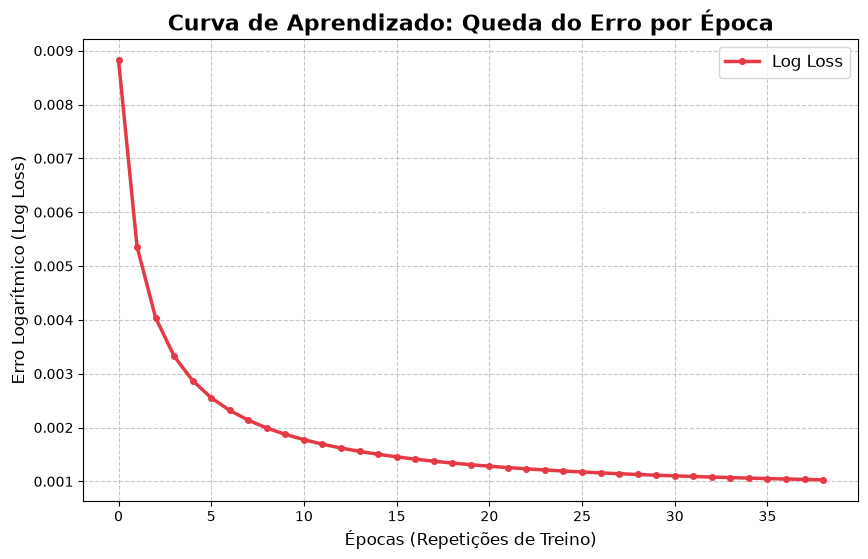

In [72]:
# 1. Define o tamanho da tela (largura x altura)
plt.figure(figsize=(10, 6))

# 2. Desenha a linha com cor personalizada, espessura (linewidth) e marcadores (marker)
plt.plot(lossHistory, color='#E63946', linewidth=2.5, marker='o', markersize=4, label='Log Loss')

# 3. Adiciona um título descritivo e altera o tamanho da fonte
plt.title('Curva de Aprendizado: Queda do Erro por Época', fontsize=16, fontweight='bold')

# 4. Nomeia os eixos X (Horizontal) e Y (Vertical)
plt.xlabel('Épocas (Repetições de Treino)', fontsize=12)
plt.ylabel('Erro Logarítmico (Log Loss)', fontsize=12)

# 5. Adiciona uma grade de fundo para facilitar a leitura dos valores exatos
plt.grid(True, linestyle='--', alpha=0.7)

# 6. Exibe a legenda indicando o que a linha significa
plt.legend(fontsize=12)

# 7. Renderiza e exibe o gráfico finalizado
plt.show()

In [ ]:
#fazendo o classificador com input 
feature = []

#feature = [13500, 430, 175, 95, 0.85, 13800, 0.70]

for entrada in range(7):
    inp = float(input(f"digite o nome da característica [{entrada + 1}]: "))
    feature.append(inp)

vetor = np.array([feature])

grao = scaler.transform(vetor)

prob = model.predict_proba(grao)[0]
previsao = model.predict(grao)

if previsao[0] == 1:
    especie = "Osmancik"
    certeza = prob[1] * 100 

else:
    especie = "Cammeo"
    certeza = prob[0] * 100
    
    
print(" -------- RELATÓRIO --------- ")
print(f"Medidas brutas lidas: {feature}")
print(f"Espécie Detectada: {especie}")
print(f"Nível de Confiança da IA: {certeza:.2f}%")
print("---------------------------------")

 -------- RELATÓRIO --------- 
Medidas brutas lidas: [13500, 430, 175, 95, 0.85, 13800, 0.7]
Espécie Detectada: Cammeo
Nível de Confiança da IA: 99.72%
---------------------------------


/Users/apple/LearningAI/venv_ia/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
